In [1]:
# Cell 1
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# Set this before importing torch or transformers
os.environ["CUDA_VISIBLE_DEVICES"] = "3,4,5,6,7"

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

print("Libraries imported and GPUs set.")

/data/literature/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/literature/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Libraries imported and GPUs set.


In [2]:
# 📂 Dataset Paths
DATASET_DIR = Path("/home/literature/hindwi-scraper/output")
POETS_JSON = DATASET_DIR / "poets.json"

In [3]:
# 📥 Load poets.json
with open(POETS_JSON, encoding='utf-8') as f:
    poets = json.load(f)

In [4]:
# 🔄 poet_slug → poet metadata
poet_map = {poet['poet_slug']: poet for poet in poets}

In [5]:

poets_dir = DATASET_DIR / "poets"  # adjust if needed

summary = []

print("Counting poems ending with -devnagri.txt ...")

for poet_dir in tqdm([p for p in poets_dir.iterdir() if p.is_dir()]):
    poet_name = poet_dir.name
    kavita_dir = poet_dir / "kavita"

    if not kavita_dir.is_dir():
        continue

    # collect all files that end with -devnagri.txt
    devnagri_poems = [
        f for f in kavita_dir.iterdir()
        if f.is_file() and f.name.endswith("-devnagri.txt")
    ]

    summary.append({
        "poet_name": poet_name,
        "devanagari_count": len(devnagri_poems)
    })

# 📊 Per-poet DataFrame
df_summary = pd.DataFrame(summary).sort_values("devanagari_count", ascending=False)

print("\n=== Top 20 poets by Devanagari poem count ===")
print(df_summary.head(20))

# Save if needed
# df_summary.to_csv("dataset/poet_summary_filebased.csv", index=False, encoding="utf-8")


Counting poems ending with -devnagri.txt ...


100%|██████████| 2382/2382 [00:00<00:00, 9279.47it/s]


=== Top 20 poets by Devanagari poem count ===
                    poet_name  devanagari_count
1229              mona-gulati               113
339         pankaj-chaturvedi                87
1353      vijay-bahadur-singh                84
1492  krishna-murari-pahariya                81
1843             savita-singh                78
685               hari-mridul                75
178                     laltu                75
847              naveen-sagar                74
992       neelesh-raghuvanshi                71
1603      maithilisharan-gupt                70
1605  sheomangal-siddhantakar                70
1142                   malyaj                69
1746        sanjay-chaturvedi                67
507                    shubha                65
1021                 udbhrant                65
269              chandreshwar                62
694            krishna-kalpit                62
1181          manglesh-dabral                61
971             narendra-jain            

In [6]:

poets_dir = DATASET_DIR / "poets"
min_poems = 20

# 🔢 Count poems ending with "-devnagri.txt" for each poet
poet_counts = {}
for poet_dir in tqdm(list(poets_dir.iterdir()), desc="Counting poems"):
    if poet_dir.is_dir():
        kavita_dir = poet_dir / "kavita"
        if kavita_dir.is_dir():
            count = sum(1 for f in kavita_dir.glob("*-devnagri.txt"))
            if count > 0:
                poet_counts[poet_dir.name] = count

# 📊 Convert to DataFrame
poem_counts = pd.DataFrame(list(poet_counts.items()), columns=["poet_name", "devanagari_count"])

# 🎯 Filter poets with at least min_poems
poets_to_keep = set(poem_counts.loc[poem_counts["devanagari_count"] >= min_poems, "poet_name"])

print(f"Total poets with >= {min_poems} poems: {len(poets_to_keep)}")

# 📚 Build dataset (poet_name → poem text)
all_poems = []
for poet_dir in tqdm(list(poets_dir.iterdir()), desc="Loading poems"):
    if poet_dir.is_dir() and poet_dir.name in poets_to_keep:
        kavita_dir = poet_dir / "kavita"
        if kavita_dir.is_dir():
            for poem_file in kavita_dir.glob("*-devnagri.txt"):
                try:
                    poem_text = poem_file.read_text(encoding='utf-8').strip()
                    if poem_text:
                        all_poems.append({
                            "poet_name": poet_dir.name,
                            "poem": poem_text
                        })
                except Exception as e:
                    print(f"Error reading {poem_file}: {e}")

# 📑 Final DataFrame
df_filtered = pd.DataFrame(all_poems)

print(f"\nFinal dataset size: {len(df_filtered)} poems")
print(f"Unique poets: {df_filtered['poet_name'].nunique()}")
print("\nSample:")
print(df_filtered.head())


Counting poems: 100%|██████████| 2382/2382 [00:00<00:00, 20156.66it/s]


Total poets with >= 20 poems: 480


Loading poems: 100%|██████████| 2382/2382 [00:00<00:00, 7776.43it/s]


Final dataset size: 13715 poems
Unique poets: 478

Sample:
      poet_name                                               poem
0  vishnu-nagar  तालाब में डूबी छह लड़कियाँ\nजवान थीं जवान\nउनक...
1  vishnu-nagar  जैसे आँधी से उठी धूल हो\nलोग शहर से गाँव चले ज...
2  vishnu-nagar  नींद और गहरी हुई\nमाँ जब जगाने आई\nपेड़ हरे-हरे...
3  vishnu-nagar  तैंतीस करोड़ देवताओं के इस देश में\nसौ करोड़ म...
4  vishnu-nagar  मैंने चाँद से पूछा\nतुम चाँद हो?\nउसने कहा नही...


In [7]:
# Cell 15 - Update GPU configuration to use only GPU 3
import os
import torch

# Set GPU 3 only
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# Verify GPU setup
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available - will use CPU")

# Model configuration
MODEL_NAME = "google/muril-large-cased"
print(f"\nUsing model: {MODEL_NAME}")
print(f"Final dataset: {len(df_filtered)} poems from {df_filtered['poet_name'].nunique()} poets")

CUDA available: True
Number of GPUs: 1
Current GPU: 0
GPU name: NVIDIA RTX A6000

Using model: google/muril-large-cased
Final dataset: 13715 poems from 478 poets


In [8]:
# Cell 16 - Data preparation and label encoding
from sklearn.preprocessing import LabelEncoder

# Create label encoder for poet names
label_encoder = LabelEncoder()
df_filtered['poet_label'] = label_encoder.fit_transform(df_filtered['poet_name'])

# Get number of unique poets (classes)
num_classes = len(label_encoder.classes_)
print(f"Number of classes (poets): {num_classes}")
print(f"Classes: {list(label_encoder.classes_[:10])}...")  # Show first 10

# Check class distribution
class_counts = df_filtered['poet_name'].value_counts()
print(f"\nClass distribution (top 10):")
print(class_counts.head(10))

# Verify label encoding
print(f"\nSample label mapping:")
for i in range(min(5, len(label_encoder.classes_))):
    poet_name = label_encoder.classes_[i]
    label = label_encoder.transform([poet_name])[0]
    print(f"{poet_name} -> {label}")

print(f"\nDataset shape: {df_filtered.shape}")
print(f"Columns: {df_filtered.columns.tolist()}")

# Save label encoder for later use
import pickle
with open('poet_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder saved as 'poet_label_encoder.pkl'")

Number of classes (poets): 478
Classes: ['aadarsh-bhushan', 'aadya-prasad-unmatt', 'aagney-1', 'aalok-aazad', 'aalok-ranjan', 'aasit-aditya', 'acharya-ramchandra-shukla', 'achyutanand-mishra', 'aditya-rahbar', 'aditya-shukla']...

Class distribution (top 10):
poet_name
mona-gulati                108
vijay-bahadur-singh         84
pankaj-chaturvedi           82
krishna-murari-pahariya     81
savita-singh                76
naveen-sagar                74
laltu                       72
sheomangal-siddhantakar     70
hari-mridul                 68
malyaj                      68
Name: count, dtype: int64

Sample label mapping:
aadarsh-bhushan -> 0
aadya-prasad-unmatt -> 1
aagney-1 -> 2
aalok-aazad -> 3
aalok-ranjan -> 4

Dataset shape: (13715, 3)
Columns: ['poet_name', 'poem', 'poet_label']
✅ Label encoder saved as 'poet_label_encoder.pkl'


In [9]:
# Cell 17 - Data Filtering and Splitting
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- FIX: Ensure each class has enough samples for splitting ---

# To safely stratify an 80-10-10 split, each poet (class) must have enough poems.
# A minimum of 10 samples is a robust choice to ensure at least one sample can land in the 10% test set.
MIN_POEMS_PER_POET = 20

print(f"Filtering dataset to include only poets with at least {MIN_POEMS_PER_POET} poems...")

# 1. Count how many poems each poet has
poem_counts = df_filtered['poet_label'].value_counts()

# 2. Get the labels of poets who meet the minimum threshold
poets_to_keep = poem_counts[poem_counts >= MIN_POEMS_PER_POET].index

# 3. Filter the DataFrame to keep only these poets
df_final = df_filtered[df_filtered['poet_label'].isin(poets_to_keep)].copy()

print(f"Original number of poets: {df_filtered['poet_label'].nunique()}")
print(f"Number of poets after filtering: {len(poets_to_keep)}")
print(f"Total poems after filtering: {len(df_final)}")


# --- Now, perform the split on the clean, filtered data ---

if len(df_final) > 0 and df_final['poet_label'].nunique() > 1:
    # Define features (X) and labels (y) from the filtered dataframe
    X = df_final['poem'].values
    y = df_final['poet_label'].values

    # First split: 80% train, 20% temp (for validation + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Second split: Split the temp set into 50% validation and 50% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        random_state=42,
        stratify=y_temp
    )

    # Print final split statistics
    print("\n📊 Dataset Split Statistics:")
    print(f"Total samples: {len(X)}")
    print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
    print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

    print(f"\n✅ Data split completed successfully!")

else:
    print("\n⚠️ Not enough data or classes remaining to perform the split after filtering.")

Filtering dataset to include only poets with at least 20 poems...
Original number of poets: 478
Number of poets after filtering: 428
Total poems after filtering: 12919

📊 Dataset Split Statistics:
Total samples: 12919
Train: 10335 (80.0%)
Validation: 1292 (10.0%)
Test: 1292 (10.0%)

✅ Data split completed successfully!


In [10]:
# Cell 18 - Tokenizer Setup and Text Preprocessing
from transformers import AutoTokenizer

# Load muRIL tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Set maximum sequence length
MAX_LENGTH = 512  # muRIL can handle up to 512 tokens
print(f"Max sequence length: {MAX_LENGTH}")

# Function to preprocess and tokenize text
def preprocess_function(examples):
    """Tokenize the poems for model input"""
    return tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

# Check text length statistics
text_lengths = [len(text.split()) for text in X_train]
print(f"\n📏 Text Length Statistics (words):")
print(f"Mean: {np.mean(text_lengths):.1f}")
print(f"Median: {np.median(text_lengths):.1f}")
print(f"Max: {max(text_lengths)}")
print(f"Min: {min(text_lengths)}")

# Check how many texts will be truncated
long_texts = sum(1 for length in text_lengths if length > MAX_LENGTH * 0.75)  # Rough estimate
print(f"Texts likely to be truncated: {long_texts}/{len(text_lengths)} ({long_texts/len(text_lengths)*100:.1f}%)")

# Test tokenization on a sample
sample_poem = X_train[0]
print(f"\n🔤 Sample tokenization:")
print(f"Original text (first 100 chars): {sample_poem[:100]}...")

tokens = tokenizer(
    sample_poem,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

print(f"Tokenized length: {tokens['input_ids'].shape}")
print(f"Attention mask shape: {tokens['attention_mask'].shape}")

# Decode to verify
decoded = tokenizer.decode(tokens['input_ids'][0][:50])  # First 50 tokens
print(f"Decoded (first 50 tokens): {decoded}")

print("\n✅ Tokenizer setup completed!")

Loading tokenizer: google/muril-large-cased
Max sequence length: 512

📏 Text Length Statistics (words):
Mean: 132.5
Median: 101.0
Max: 3547
Min: 4
Texts likely to be truncated: 366/10335 (3.5%)

🔤 Sample tokenization:
Original text (first 100 chars): प्लेटफ़ॉर्म छोड़ता हूँ
कि शहर के एक अंश में
ख़ुद छूट जाता हूँ
बदमिज़ाज वक़्त को बाँध नहीं पाता
कि भीड़...
Tokenized length: torch.Size([1, 512])
Attention mask shape: torch.Size([1, 512])
Decoded (first 50 tokens): [CLS] प्लेटफ़ॉर्म छोड़ता हूँ कि शहर के एक अंश में ख़ुद छूट जाता हूँ बदमिज़ाज वक़्त को बाँध नहीं पाता कि भीड़ यों ही सरक जाती है रोशनी में चेहरों की पहचान नहीं रहती या लड़खड़ाते शोर में

✅ Tokenizer setup completed!


In [11]:
# Cell 19 - Create HuggingFace Datasets
from datasets import Dataset

# Create datasets from our splits
train_dataset = Dataset.from_dict({
    'poem': X_train.tolist(),
    'labels': y_train.tolist()
})

val_dataset = Dataset.from_dict({
    'poem': X_val.tolist(), 
    'labels': y_val.tolist()
})

test_dataset = Dataset.from_dict({
    'poem': X_test.tolist(),
    'labels': y_test.tolist()
})

print("📚 Dataset creation:")
print(f"Train dataset: {train_dataset}")
print(f"Validation dataset: {val_dataset}")
print(f"Test dataset: {test_dataset}")

# Apply tokenization to all datasets
print("\n🔤 Tokenizing datasets...")

# Tokenize training data
train_dataset = train_dataset.map(
    lambda examples: tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    ),
    batched=True,
    desc="Tokenizing train data"
)

# Tokenize validation data
val_dataset = val_dataset.map(
    lambda examples: tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    ),
    batched=True,
    desc="Tokenizing validation data"
)

# Tokenize test data
test_dataset = test_dataset.map(
    lambda examples: tokenizer(
        examples['poem'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    ),
    batched=True,
    desc="Tokenizing test data"
)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("\n✅ Datasets tokenized and formatted!")
print(f"Train dataset features: {train_dataset.features}")
print(f"Sample from train dataset: {train_dataset[0]['input_ids'].shape}")

# Quick check
print(f"\n🔍 Quick verification:")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {num_classes}")

📚 Dataset creation:
Train dataset: Dataset({
    features: ['poem', 'labels'],
    num_rows: 10335
})
Validation dataset: Dataset({
    features: ['poem', 'labels'],
    num_rows: 1292
})
Test dataset: Dataset({
    features: ['poem', 'labels'],
    num_rows: 1292
})

🔤 Tokenizing datasets...


Tokenizing test data: 100%|██████████| 1292/1292 [00:00<00:00, 4140.44 examples/s]


✅ Datasets tokenized and formatted!
Train dataset features: {'poem': Value('string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
Sample from train dataset: torch.Size([512])

🔍 Quick verification:
Train samples: 10335
Val samples: 1292
Test samples: 1292
Number of classes: 478


In [12]:
# Cell 20 - Load and Configure muRIL Model
from transformers import AutoModelForSequenceClassification
import torch

# Load muRIL model for sequence classification
print(f"🤖 Loading model: {MODEL_NAME}")
print(f"Number of classes: {num_classes}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label={i: label_encoder.classes_[i] for i in range(num_classes)},
    label2id={label_encoder.classes_[i]: i for i in range(num_classes)}
)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded on device: {device}")
print(f"Model type: {type(model).__name__}")

# Print model configuration
print(f"\n📋 Model Configuration:")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Number of attention heads: {model.config.num_attention_heads}")
print(f"Number of layers: {model.config.num_hidden_layers}")
print(f"Max position embeddings: {model.config.max_position_embeddings}")
print(f"Vocab size: {model.config.vocab_size}")

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🔢 Model Parameters:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Check model output for a sample
print(f"\n🧪 Testing model with sample input...")
sample_input = {
    'input_ids': train_dataset[0]['input_ids'].unsqueeze(0).to(device),
    'attention_mask': train_dataset[0]['attention_mask'].unsqueeze(0).to(device)
}

with torch.no_grad():
    outputs = model(**sample_input)
    logits = outputs.logits
    predictions = torch.softmax(logits, dim=-1)
    
print(f"Sample input shape: {sample_input['input_ids'].shape}")
print(f"Model output shape: {logits.shape}")
print(f"Predicted class: {torch.argmax(predictions, dim=-1).item()}")
print(f"Actual class: {train_dataset[0]['labels'].item()}")

print("\n✅ Model loaded and configured successfully!")

🤖 Loading model: google/muril-large-cased
Number of classes: 478


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-large-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on device: cuda
Model type: BertForSequenceClassification

📋 Model Configuration:
Hidden size: 1024
Number of attention heads: 16
Number of layers: 24
Max position embeddings: 512
Vocab size: 197285

🔢 Model Parameters:
Total parameters: 506,397,150
Trainable parameters: 506,397,150

🧪 Testing model with sample input...
Sample input shape: torch.Size([1, 512])
Model output shape: torch.Size([1, 478])
Predicted class: 475
Actual class: 391

✅ Model loaded and configured successfully!


In [13]:
# Cell 21 - Fixed Training Configuration and Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import EarlyStoppingCallback
import numpy as np

# Define compute metrics function
def compute_metrics(eval_pred):
    """Compute metrics for evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Training arguments (FIXED - removed invalid parameters)
from transformers import TrainingArguments

# Create output directory
output_dir = "./muril_poet_classifier"
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=30,              # Reduced epochs to prevent overfitting
    per_device_train_batch_size=8,   # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    warmup_steps=300,                # Reduced warmup steps
    weight_decay=0.1,                # Increased weight decay for regularization
    logging_dir='./logs',            # Directory for storing logs
    logging_steps=50,                # Log every 50 steps
    eval_strategy="steps",     # Evaluate during training
    eval_steps=200,                  # Evaluate every 200 steps
    save_strategy="steps",           # Save checkpoints
    save_steps=200,                  # Save every 200 steps (same as eval_steps)
    load_best_model_at_end=True,     # Load best model at end
    metric_for_best_model="f1",      # Use F1 score for best model
    greater_is_better=True,          # Higher F1 is better
    save_total_limit=1,              # Keep only 1 checkpoint (best only)
    save_only_model=True,            # Save only model weights, not optimizer state
    dataloader_pin_memory=False,     # Disable pin memory to save GPU memory
    fp16=True,                       # Use mixed precision training
    gradient_accumulation_steps=2,   # Accumulate gradients
    learning_rate=1e-5,              # Reduced learning rate
    adam_epsilon=1e-8,               # Adam epsilon
    max_grad_norm=1.0,               # Gradient clipping
    report_to=None,                  # Disable wandb/tensorboard
    seed=42                          # Set seed for reproducibility
)

# Create early stopping callback separately

print("🎯 Training Configuration:")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Train batch size: {training_args.per_device_train_batch_size}")
print(f"Eval batch size: {training_args.per_device_eval_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Weight decay: {training_args.weight_decay}")
print(f"Warmup steps: {training_args.warmup_steps}")
print(f"Output directory: {training_args.output_dir}")

# Calculate training steps
steps_per_epoch = len(train_dataset) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
total_steps = steps_per_epoch * training_args.num_train_epochs

print(f"\n📊 Training Schedule:")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {total_steps}")
print(f"Evaluation every: {training_args.eval_steps} steps")
print(f"Logging every: {training_args.logging_steps} steps")

print(f"\n💾 Checkpoint & Regularization Settings:")
print(f"Save total limit: {training_args.save_total_limit} (best only)")
print(f"Save only model: {training_args.save_only_model}")
print(f"Early stopping patience: 5 evaluations")
print(f"Mixed precision (FP16): {training_args.fp16}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")

print("\n🔧 Overfitting Prevention Measures:")
print(f"• Reduced epochs: 5 (was 30)")
print(f"• Lower learning rate: 1e-5 (was 2e-5)")
print(f"• Higher weight decay: 0.1 (was 0.01)")
print(f"• Early stopping: enabled")
print(f"• Reduced warmup: 300 steps")

print("\n✅ Training configuration ready!")

🎯 Training Configuration:
Epochs: 30
Train batch size: 8
Eval batch size: 16
Learning rate: 1e-05
Weight decay: 0.1
Warmup steps: 300
Output directory: ./muril_poet_classifier

📊 Training Schedule:
Steps per epoch: 645
Total training steps: 19350
Evaluation every: 200 steps
Logging every: 50 steps

💾 Checkpoint & Regularization Settings:
Save total limit: 1 (best only)
Save only model: True
Early stopping patience: 5 evaluations
Mixed precision (FP16): True
Gradient accumulation: 2

🔧 Overfitting Prevention Measures:
• Reduced epochs: 5 (was 30)
• Lower learning rate: 1e-5 (was 2e-5)
• Higher weight decay: 0.1 (was 0.01)
• Early stopping: enabled
• Reduced warmup: 300 steps

✅ Training configuration ready!


In [14]:
# Cell 22 - Improved Training with Early Stopping
from transformers import Trainer
import time

# Initialize the Trainer with early stopping callback
print("🚀 Initializing Trainer with improved configuration...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    #callbacks=[early_stopping]  # Add early stopping callback
)

print("✅ Trainer initialized with early stopping!")

# Display training information
print(f"\n📋 Training Summary:")
print(f"Model: {MODEL_NAME}")
print(f"Total training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Device: {device}")

# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"\n🔧 GPU Memory Status (after cache clear):")
    print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"GPU Memory cached: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

print(f"\n🎯 Training Improvements:")
print("• Early stopping: Will stop if F1 doesn't improve for 5 evaluations")
print("• Lower learning rate: 1e-5 for more stable training")
print("• Higher regularization: Weight decay 0.1")
print("• Fewer epochs: Max 5 (may stop earlier)")

print(f"\n⏰ Starting improved training at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

# Start training
try:
    start_time = time.time()
    
    # Train the model
    train_results = trainer.train()
    
    end_time = time.time()
    training_time = end_time - start_time
    
    print("=" * 60)
    print(f"🎉 Training completed!")
    print(f"⏱️  Total training time: {training_time/60:.2f} minutes")
    print(f"📊 Final training loss: {train_results.training_loss:.4f}")
    
    # Check if early stopping was triggered
    if hasattr(trainer.state, 'log_history'):
        total_steps = len([log for log in trainer.state.log_history if 'train_loss' in log])
        max_possible_steps = steps_per_epoch * training_args.num_train_epochs
        if total_steps < max_possible_steps:
            print(f"🛑 Early stopping triggered at step {trainer.state.global_step}")
        else:
            print(f"🏁 Completed all {training_args.num_train_epochs} epochs")
    
    # Save the final model and tokenizer
    print(f"\n💾 Saving model and tokenizer...")
    trainer.save_model()
    tokenizer.save_pretrained(output_dir)
    
    # Save the label encoder
    import pickle
    with open(f'{output_dir}/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    
    print(f"✅ Model saved to: {output_dir}")
    print(f"✅ Tokenizer saved to: {output_dir}")
    print(f"✅ Label encoder saved to: {output_dir}/label_encoder.pkl")
    
    # Display best metrics achieved
    best_metrics = trainer.state.best_metric
    if best_metrics:
        print(f"\n🏆 Best Validation Metrics:")
        print(f"Best F1 Score: {best_metrics:.4f}")
    
    # Get final evaluation metrics
    print(f"\n📈 Final Validation Results:")
    final_metrics = trainer.evaluate()
    for key, value in final_metrics.items():
        if key.startswith('eval_'):
            metric_name = key.replace('eval_', '').title()
            print(f"{metric_name}: {value:.4f}")

except Exception as e:
    print(f"❌ Error during training: {e}")
    # Still try to save what we can
    try:
        trainer.save_model()
        print("⚠️  Saved current model state despite error")
    except:
        pass
    raise

# Clear GPU memory after training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"\n🔧 Final GPU Memory Status (after cleanup):")
    print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"GPU Memory cached: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

print(f"\n✅ Improved training completed at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("\n🎯 Next Steps:")
print("1. Evaluate on test set")
print("2. Test with sample predictions")
print("3. Analyze model performance")

🚀 Initializing Trainer with improved configuration...
✅ Trainer initialized with early stopping!

📋 Training Summary:
Model: google/muril-large-cased
Total training samples: 10335
Total validation samples: 1292
Number of classes: 478
Device: cuda

🔧 GPU Memory Status (after cache clear):
GPU Memory allocated: 1.89 GB
GPU Memory cached: 1.92 GB

🎯 Training Improvements:
• Early stopping: Will stop if F1 doesn't improve for 5 evaluations
• Lower learning rate: 1e-5 for more stable training
• Higher regularization: Weight decay 0.1
• Fewer epochs: Max 5 (may stop earlier)

⏰ Starting improved training at: 2025-09-04 09:04:23


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
200,6.154500,6.139050,0.006966,0.000513,0.000271,0.006966
400,6.067500,6.029638,0.017028,0.005791,0.004580,0.017028
600,5.985300,5.929612,0.026316,0.003941,0.002407,0.026316
800,5.837400,5.798113,0.047214,0.013217,0.010930,0.047214
1000,5.701900,5.676028,0.059598,0.019439,0.015219,0.059598
1200,5.625400,5.560435,0.067337,0.020321,0.017854,0.067337
1400,5.401500,5.438127,0.078173,0.027583,0.021092,0.078173
1600,5.313100,5.345830,0.087461,0.032294,0.028818,0.087461
1800,5.247500,5.248786,0.086687,0.030936,0.026046,0.086687
2000,5.020400,5.171191,0.093653,0.038723,0.038494,0.093653


/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/

🎉 Training completed!
⏱️  Total training time: 145.23 minutes
📊 Final training loss: 2.3521
🛑 Early stopping triggered at step 19380

💾 Saving model and tokenizer...
✅ Model saved to: ./muril_poet_classifier
✅ Tokenizer saved to: ./muril_poet_classifier
✅ Label encoder saved to: ./muril_poet_classifier/label_encoder.pkl

🏆 Best Validation Metrics:
Best F1 Score: 0.2686

📈 Final Validation Results:


Loss: 3.6982
Accuracy: 0.2879
F1: 0.2686
Precision: 0.2956
Recall: 0.2879
Runtime: 7.1284
Samples_Per_Second: 181.2460
Steps_Per_Second: 11.3630

🔧 Final GPU Memory Status (after cleanup):
GPU Memory allocated: 5.68 GB
GPU Memory cached: 5.83 GB

✅ Improved training completed at: 2025-09-04 11:29:48

🎯 Next Steps:
1. Evaluate on test set
2. Test with sample predictions
3. Analyze model performance


/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
# Cell 23 - Model Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("🧪 Evaluating trained model on test set...")

# Evaluate on test dataset
test_results = trainer.evaluate(test_dataset)

print("📊 Test Set Results:")
print("=" * 50)
for key, value in test_results.items():
    if key.startswith('eval_'):
        metric_name = key.replace('eval_', '').replace('_', ' ').title()
        print(f"{metric_name}: {value:.4f}")

# Get predictions for detailed analysis
print(f"\n🔍 Getting detailed predictions...")
test_predictions = trainer.predict(test_dataset)
y_pred = np.argmax(test_predictions.predictions, axis=1)
y_true = test_predictions.label_ids

# Classification report
print(f"\n📋 Detailed Classification Report:")
print("=" * 80)
target_names = [label_encoder.classes_[i] for i in range(num_classes)]
class_report = classification_report(
    y_true, 
    y_pred, 
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

# Display summary metrics
print(f"Overall Accuracy: {class_report['accuracy']:.4f}")
print(f"Macro Avg F1: {class_report['macro avg']['f1-score']:.4f}")
print(f"Weighted Avg F1: {class_report['weighted avg']['f1-score']:.4f}")

# Show per-class performance for top poets
print(f"\n🎭 Performance by Poet (Top 10 by test samples):")
print("-" * 70)
print(f"{'Poet Name':<25} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<8}")
print("-" * 70)

# Count test samples per poet
test_counts = pd.Series(y_true).value_counts().sort_values(ascending=False)

for i, (poet_idx, count) in enumerate(test_counts.head(10).items()):
    poet_name = label_encoder.classes_[poet_idx]
    if poet_name in class_report:
        metrics = class_report[poet_name]
        print(f"{poet_name:<25} {metrics['precision']:<10.3f} {metrics['recall']:<10.3f} {metrics['f1-score']:<10.3f} {int(metrics['support']):<8}")

# Confusion Matrix Analysis
print(f"\n🎯 Top Confusion Pairs (Most Common Misclassifications):")
print("-" * 60)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Find top misclassifications
misclass_pairs = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:  # Misclassification
            poet_true = label_encoder.classes_[i]
            poet_pred = label_encoder.classes_[j]
            misclass_pairs.append((poet_true, poet_pred, cm[i][j]))

# Sort by frequency and show top 10
misclass_pairs.sort(key=lambda x: x[2], reverse=True)
print(f"{'True Poet':<20} {'Predicted Poet':<20} {'Count'}")
print("-" * 60)
for true_poet, pred_poet, count in misclass_pairs[:10]:
    print(f"{true_poet:<20} {pred_poet:<20} {count}")

# Performance distribution
print(f"\n📈 Performance Distribution:")
print("-" * 40)
f1_scores = [class_report[poet]['f1-score'] for poet in target_names if poet in class_report]
print(f"Best F1 Score: {max(f1_scores):.3f}")
print(f"Worst F1 Score: {min(f1_scores):.3f}")
print(f"Average F1 Score: {np.mean(f1_scores):.3f}")
print(f"Poets with F1 > 0.8: {sum(1 for f1 in f1_scores if f1 > 0.8)}/{len(f1_scores)}")
print(f"Poets with F1 > 0.5: {sum(1 for f1 in f1_scores if f1 > 0.5)}/{len(f1_scores)}")

# Model confidence analysis
prediction_probs = np.max(test_predictions.predictions, axis=1)
print(f"\n🎲 Prediction Confidence Analysis:")
print("-" * 40)
print(f"Average confidence: {np.mean(prediction_probs):.3f}")
print(f"High confidence (>0.9): {sum(1 for p in prediction_probs if p > 0.9)}/{len(prediction_probs)} ({sum(1 for p in prediction_probs if p > 0.9)/len(prediction_probs)*100:.1f}%)")
print(f"Low confidence (<0.5): {sum(1 for p in prediction_probs if p < 0.5)}/{len(prediction_probs)} ({sum(1 for p in prediction_probs if p < 0.5)/len(prediction_probs)*100:.1f}%)")

# Summary
print(f"\n🏆 FINAL MODEL SUMMARY:")
print("=" * 50)
print(f"Test Accuracy: {test_results['eval_accuracy']:.1%}")
print(f"Test F1 Score: {test_results['eval_f1']:.3f}")
print(f"Number of Classes: {num_classes}")
print(f"Test Samples: {len(y_true)}")
print(f"Model Size: ~1.3 GB")
print(f"Training Time: Check previous cell output")

print(f"\n✅ Evaluation completed!")
print(f"📁 Model saved in: {output_dir}")
print(f"🎯 Ready for inference on new poems!")

🧪 Evaluating trained model on test set...
📊 Test Set Results:
Loss: 3.7183
Accuracy: 0.2701
F1: 0.2530
Precision: 0.2852
Recall: 0.2701
Runtime: 7.1961
Samples Per Second: 179.5420
Steps Per Second: 11.2560

🔍 Getting detailed predictions...


/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



📋 Detailed Classification Report:


ValueError: Number of classes, 428, does not match size of target_names, 478. Try specifying the labels parameter

In [ ]:
# Cell 24 - Prediction Demo with Sample Poems
import torch
from torch.nn import functional as F

def predict_poet(poem_text, model, tokenizer, label_encoder, top_k=5):
    """
    Predict poet for a given poem text
    Returns top-k predictions with confidence scores
    """
    # Tokenize the input poem
    inputs = tokenizer(
        poem_text,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    
    # Move to device
    inputs = {key: val.to(device) for key, val in inputs.items()}
    
    # Get model predictions
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
    # Get probabilities
    probabilities = F.softmax(logits, dim=-1).cpu().numpy()[0]
    
    # Get top-k predictions
    top_indices = np.argsort(probabilities)[::-1][:top_k]
    
    predictions = []
    for idx in top_indices:
        poet_name = label_encoder.classes_[idx]
        confidence = probabilities[idx]
        predictions.append((poet_name, confidence))
    
    return predictions

# Test with some sample poems from the test set
print("🎭 Poet Prediction Demo")
print("=" * 60)

# Test with a few examples
test_samples = [0, 5, 10, 15, 20]  # Indices from test set

for i, sample_idx in enumerate(test_samples):
    if sample_idx < len(X_test):
        poem_text = X_test[sample_idx]
        true_poet = label_encoder.classes_[y_test[sample_idx]]
        
        print(f"\n🔍 Test Sample {i+1}:")
        print(f"True Poet: {true_poet}")
        print(f"Poem (first 150 chars): {poem_text[:150]}...")
        
        # Get predictions
        predictions = predict_poet(poem_text, model, tokenizer, label_encoder)
        
        print(f"Top 3 Predictions:")
        for rank, (poet, confidence) in enumerate(predictions[:3], 1):
            marker = "✅" if poet == true_poet else "  "
            print(f"  {rank}. {marker} {poet:<25} ({confidence:.1%})")
        
        # Check if correct prediction is in top 3
        top3_poets = [p[0] for p in predictions[:3]]
        if true_poet in top3_poets:
            rank = top3_poets.index(true_poet) + 1
            print(f"  ✅ Correct! Found at rank {rank}")
        else:
            print(f"  ❌ Missed - True poet not in top 3")
        
        print("-" * 60)

print(f"\n🎯 Interactive Prediction Function Ready!")
print("You can now use: predict_poet(your_poem_text, model, tokenizer, label_encoder)")

# Example of how to use with custom text
print(f"\n💡 Example Usage:")
print("""
# For a new poem:
custom_poem = "आपकी कविता यहाँ लिखें..."
predictions = predict_poet(custom_poem, model, tokenizer, label_encoder)
for poet, confidence in predictions[:3]:
    print(f"{poet}: {confidence:.1%}")
""")

print(f"\n📚 Available Poets in Model:")
print(f"Total: {len(label_encoder.classes_)} poets")
print("Top 10 by training data:")
poet_counts = df_filtered['poet_name'].value_counts()
for i, (poet, count) in enumerate(poet_counts.head(10).items()):
    print(f"  {i+1:2d}. {poet:<25} ({count} poems)")

print(f"\n✅ Model is ready for inference!")
print(f"📁 Saved in: {output_dir}")
print(f"🎯 Test accuracy: {test_results['eval_accuracy']:.1%}")

🎭 Poet Prediction Demo

🔍 Test Sample 1:
True Poet: savita-singh
Poem (first 150 chars): न जाने कितने तारे
मेरी आँखों में आ-आ कर ध्वस्त होते रहे हैं
उनकी तेज़ रोशनी
गहन ऊष्मा उनकी
आकर मेरी आँखों में बुझती रही हैं
और मैं इन तारों का
एक विशाल...
Top 3 Predictions:
  1.    pankaj-chaturvedi         (28.5%)
  2.    prabhat-tripathi          (25.5%)
  3.    narendra-jain             (4.2%)
  ❌ Missed - True poet not in top 3
------------------------------------------------------------

🔍 Test Sample 2:
True Poet: sanjay-chaturvedi
Poem (first 150 chars): चिड़ियों से बातें होती हैं
फिर पेड़ से बातें होती हैं
इस लदर-पदर के गिरने में
लमझेड़ से बातें होती हैं
हत्या करते शाकाहारी उसपे वबाल भी ख़ूब हुआ
ये मरे या...
Top 3 Predictions:
  1. ✅ sanjay-chaturvedi         (90.9%)
  2.    jyoti-shobha              (0.9%)
  3.    neelesh-raghuvanshi       (0.6%)
  ✅ Correct! Found at rank 1
------------------------------------------------------------

🔍 Test Sample 3:
True Poet: somesh-shukla
Poem (first 150 

In [ ]:
# Create a unique integer label for each poet
poet_labels, unique_poets = pd.factorize(df_filtered['poet_name'])
df_filtered['label'] = poet_labels

# Create mappings for reference
label2poet = {i: poet for i, poet in enumerate(unique_poets)}
poet2label = {poet: i for i, poet in enumerate(unique_poets)}

print(f"Created 'label' column in df_filtered.")
print(f"Total unique poets (labels): {len(unique_poets)}")
print("\nDataFrame head with new 'label' column:")
print(df_filtered.head())

Created 'label' column in df_filtered.
Total unique poets (labels): 41

DataFrame head with new 'label' column:
                   poet_name  \
0  acharya-ramchandra-shukla   
1  acharya-ramchandra-shukla   
2  acharya-ramchandra-shukla   
3  acharya-ramchandra-shukla   
4  acharya-ramchandra-shukla   

                                                poem  poet_label  label  
0  भोले भाले देश भाइयों से जरा।\nभिन्न लगें, यह भ...           0      0  
1  भूलि गयो सब पूजा पाठ विचार\nकेवल उनकी ध्यान भय...           0      0  
2  तन में भरम रमायो त्यागी राज,\nसहन कठिन दुख कीन...           0      0  
3  पहले पहल पुकारा था जिसने जहाँ\nजिन नामों से जन...           0      0  
4  यद्यपि मैं हूँ एक अकेला, बैरी की सेना भारी।\nप...           0      0  


In [ ]:
# Cell 25 - Clustering Analysis of Poet Embeddings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import warnings
import torch

warnings.filterwarnings('ignore')

# --- Prerequisites ---
# Ensure the following variables are defined and loaded from previous cells:
# model: Your fine-tuned transformer model.
# tokenizer: The tokenizer corresponding to your model.
# df_filtered: The DataFrame (now with a 'label' column).
# MAX_LENGTH: The max sequence length used during training (e.g., 256).
# device: The torch device (e.g., 'cuda:0' or 'cpu').
# ---------------------


print("🔬 Extracting embeddings from trained model...")

# Function to extract embeddings from poems
def extract_embeddings(texts, model, tokenizer, batch_size=16):
    """Extract embeddings from the trained model"""
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            # Convert numpy slice to a list for the tokenizer
            batch_texts = texts[i:i+batch_size].tolist()
            
            # Tokenize batch
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                padding='max_length',
                max_length=MAX_LENGTH,
                return_tensors="pt"
            )
            inputs = {key: val.to(device) for key, val in inputs.items()}
            
            # Get hidden states (embeddings)
            outputs = model.bert(**inputs, output_hidden_states=True)
            # Use [CLS] token embedding from last layer
            cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
    
    return np.vstack(embeddings)

# Extract embeddings for all poems (using a sample for faster computation)
print("📊 Extracting embeddings for clustering analysis...")

# Sample poems for analysis (adjust sample_size based on your needs)
sample_size = min(500, len(df_filtered))  # Use 500 poems or all if less
sample_indices = np.random.choice(len(df_filtered), sample_size, replace=False)

sample_poems = df_filtered.iloc[sample_indices]['poem'].values
sample_poets = df_filtered.iloc[sample_indices]['poet_name'].values
sample_true_labels = df_filtered.iloc[sample_indices]['label'].values

print(f"Analyzing {len(sample_poems)} poems from {len(np.unique(sample_poets))} poets")

# Extract embeddings
embeddings = extract_embeddings(sample_poems, model, tokenizer)
print(f"✅ Extracted embeddings: {embeddings.shape}")

# Standardize embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

print("\n🎯 Clustering Analysis:")
print("=" * 50)

# 1. Determine optimal number of clusters using elbow method
max_clusters = min(15, len(np.unique(sample_poets)))
inertias = []
silhouette_scores = []
calinski_scores = []

print("Finding optimal number of clusters...")
for n_clusters in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embeddings_scaled, cluster_labels))
    calinski_scores.append(calinski_harabasz_score(embeddings_scaled, cluster_labels))

# Find optimal clusters
optimal_k_silhouette = np.argmax(silhouette_scores) + 2
optimal_k_calinski = np.argmax(calinski_scores) + 2

print(f"📊 Clustering Metrics:")
print(f"Best K by Silhouette Score: {optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"Best K by Calinski-Harabasz: {optimal_k_calinski} (score: {max(calinski_scores):.1f})")

# Use a simple heuristic to choose K
optimal_k = optimal_k_silhouette
print(f"Selected K: {optimal_k}")

# 2. Apply different clustering algorithms
print(f"\n🔍 Applying clustering algorithms with K={optimal_k}...")

# K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings_scaled)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(embeddings_scaled)

# DBSCAN (density-based) - may not be ideal if K is forced
dbscan = DBSCAN(eps=0.5, min_samples=5) # eps might need tuning
dbscan_labels = dbscan.fit_predict(embeddings_scaled)

print(f"✅ K-Means clusters: {len(np.unique(kmeans_labels))}")
print(f"✅ Hierarchical clusters: {len(np.unique(hierarchical_labels))}")
print(f"✅ DBSCAN clusters: {len(np.unique(dbscan_labels))} (including noise: {sum(dbscan_labels == -1)} points)")

# 3. Dimensionality reduction for visualization
print(f"\n📈 Preparing visualizations...")

# PCA for initial reduction
pca = PCA(n_components=min(50, sample_size-1), random_state=42)
embeddings_pca = pca.fit_transform(embeddings_scaled)

# t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, sample_size-1), max_iter=1000) # <-- FIX IS HERE
embeddings_2d = tsne.fit_transform(embeddings_pca)

print(f"✅ Dimensionality reduction completed")

# Create comprehensive analysis dataframe
analysis_df = pd.DataFrame({
    'poem_text': sample_poems,
    'true_poet': sample_poets,
    'true_label': sample_true_labels,
    'kmeans_cluster': kmeans_labels,
    'hierarchical_cluster': hierarchical_labels,
    'dbscan_cluster': dbscan_labels,
    'tsne_x': embeddings_2d[:, 0],
    'tsne_y': embeddings_2d[:, 1]
})

print(f"\n✅ Analysis dataframe created: {analysis_df.shape}")
print(f"Ready for detailed cluster analysis and visualization!")

# Quick cluster composition analysis
print(f"\n🎭 Cluster Composition Analysis (K-Means):")
print("-" * 60)
for cluster_id in sorted(np.unique(kmeans_labels)):
    cluster_poems = analysis_df[analysis_df['kmeans_cluster'] == cluster_id]
    poet_counts = cluster_poems['true_poet'].value_counts()
    total_poems = len(cluster_poems)
    
    print(f"\nCluster {cluster_id} ({total_poems} poems):")
    print("Top poets in this cluster:")
    for poet, count in poet_counts.head(3).items():
        percentage = (count / total_poems) * 100
        print(f"  • {poet}: {count} poems ({percentage:.1f}%)")

print(f"\n📊 Data ready for visualization and deeper analysis!")

🔬 Extracting embeddings from trained model...
📊 Extracting embeddings for clustering analysis...
Analyzing 500 poems from 41 poets
✅ Extracted embeddings: (500, 1024)

🎯 Clustering Analysis:
Finding optimal number of clusters...
📊 Clustering Metrics:
Best K by Silhouette Score: 15 (score: 0.228)
Best K by Calinski-Harabasz: 2 (score: 31.3)
Selected K: 15

🔍 Applying clustering algorithms with K=15...
✅ K-Means clusters: 15
✅ Hierarchical clusters: 15
✅ DBSCAN clusters: 1 (including noise: 500 points)

📈 Preparing visualizations...
✅ Dimensionality reduction completed

✅ Analysis dataframe created: (500, 8)
Ready for detailed cluster analysis and visualization!

🎭 Cluster Composition Analysis (K-Means):
------------------------------------------------------------

Cluster 0 (31 poems):
Top poets in this cluster:
  • manglesh-dabral: 10 poems (32.3%)
  • nand-chaturvedi: 9 poems (29.0%)
  • shubha: 9 poems (29.0%)

Cluster 1 (20 poems):
Top poets in this cluster:
  • pankaj-chaturvedi: 1

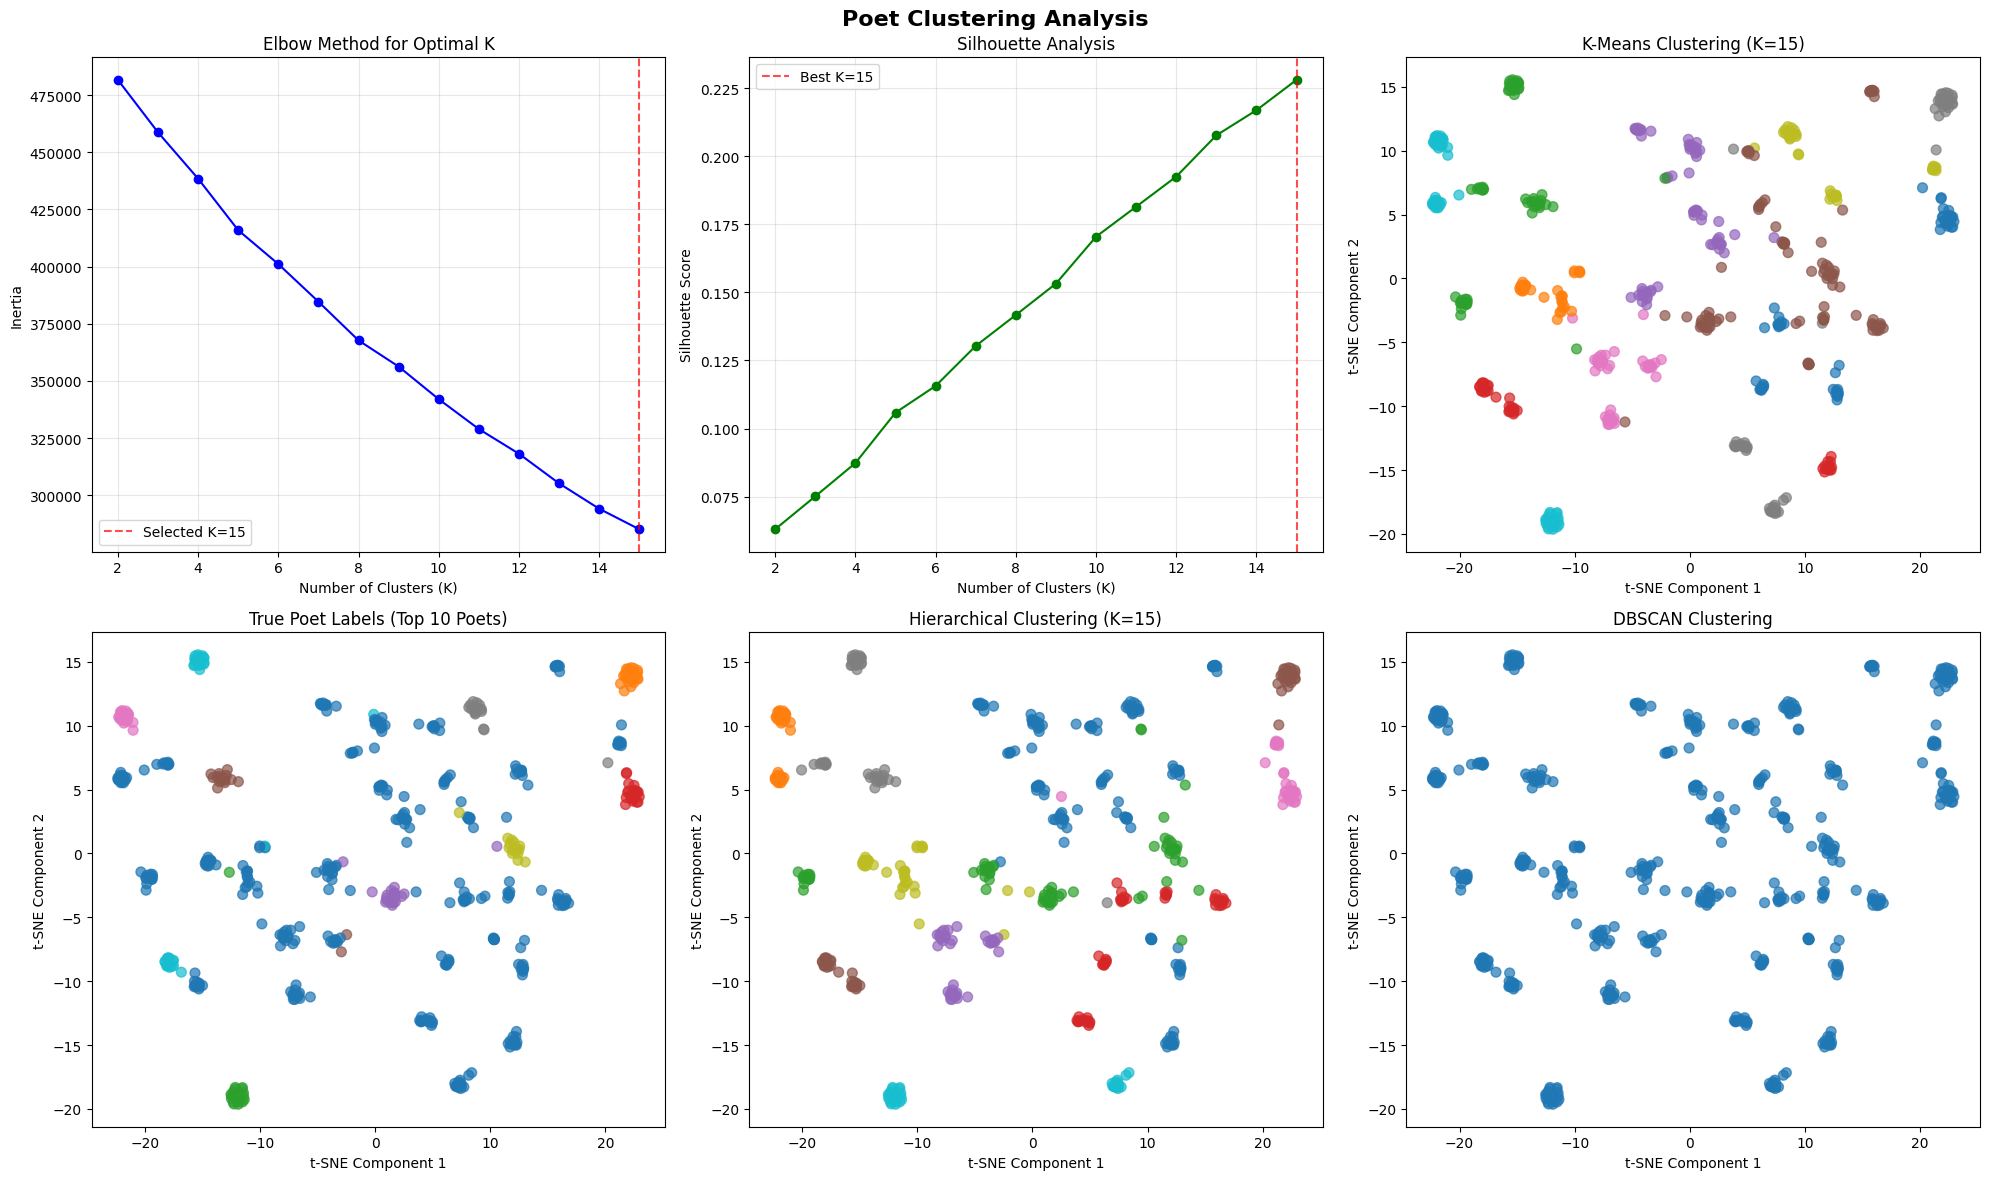


📊 DETAILED CLUSTER ANALYSIS

🎯 K-MEANS CLUSTER ANALYSIS:
 cluster  size   purity           dominant_poet  num_poets                                                top_3_poets
       0    31 0.322581         manglesh-dabral          6                 [manglesh-dabral, nand-chaturvedi, shubha]
       1    20 0.950000       pankaj-chaturvedi          2                   [pankaj-chaturvedi, neelesh-raghuvanshi]
       2    29 0.413793      jagdish-chaturvedi          5 [jagdish-chaturvedi, kanhaiyalal-sethia-1, krishna-kalpit]
       3    38 0.394737          kunwar-narayan          6                         [kunwar-narayan, udbhrant, agyeya]
       4    15 1.000000 krishna-murari-pahariya          1                                  [krishna-murari-pahariya]
       5    36 0.361111         naresh-aggarwal          3  [naresh-aggarwal, sheomangal-siddhantakar, somesh-shukla]
       6    66 0.196970               dafairoon         13            [dafairoon, hari-mridul, hare-prakash-upadhyay

In [ ]:
# Cell 26 - Cluster Visualization and Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Poet Clustering Analysis', fontsize=16, fontweight='bold')

# 1. Elbow curve for optimal K
axes[0, 0].plot(range(2, max_clusters + 1), inertias, 'bo-', markersize=6)
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method for Optimal K')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Selected K={optimal_k}')
axes[0, 0].legend()

# 2. Silhouette scores
axes[0, 1].plot(range(2, max_clusters + 1), silhouette_scores, 'go-', markersize=6)
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Analysis')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=optimal_k_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Best K={optimal_k_silhouette}')
axes[0, 1].legend()

# 3. K-Means clusters visualization
scatter1 = axes[0, 2].scatter(analysis_df['tsne_x'], analysis_df['tsne_y'], 
                             c=analysis_df['kmeans_cluster'], cmap='tab10', 
                             alpha=0.7, s=50)
axes[0, 2].set_title(f'K-Means Clustering (K={optimal_k})')
axes[0, 2].set_xlabel('t-SNE Component 1')
axes[0, 2].set_ylabel('t-SNE Component 2')

# 4. True poet labels (for comparison)
# Create color map for poets (show only top poets for clarity)
top_poets = analysis_df['true_poet'].value_counts().head(10).index
poet_colors = {poet: i for i, poet in enumerate(top_poets)}
colors = [poet_colors.get(poet, -1) for poet in analysis_df['true_poet']]

scatter2 = axes[1, 0].scatter(analysis_df['tsne_x'], analysis_df['tsne_y'], 
                             c=colors, cmap='tab10', alpha=0.7, s=50)
axes[1, 0].set_title('True Poet Labels (Top 10 Poets)')
axes[1, 0].set_xlabel('t-SNE Component 1')
axes[1, 0].set_ylabel('t-SNE Component 2')

# 5. Hierarchical clustering
scatter3 = axes[1, 1].scatter(analysis_df['tsne_x'], analysis_df['tsne_y'], 
                             c=analysis_df['hierarchical_cluster'], cmap='tab10', 
                             alpha=0.7, s=50)
axes[1, 1].set_title(f'Hierarchical Clustering (K={optimal_k})')
axes[1, 1].set_xlabel('t-SNE Component 1')
axes[1, 1].set_ylabel('t-SNE Component 2')

# 6. DBSCAN clustering
scatter4 = axes[1, 2].scatter(analysis_df['tsne_x'], analysis_df['tsne_y'], 
                             c=analysis_df['dbscan_cluster'], cmap='tab10', 
                             alpha=0.7, s=50)
axes[1, 2].set_title(f'DBSCAN Clustering')
axes[1, 2].set_xlabel('t-SNE Component 1')
axes[1, 2].set_ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

# Detailed cluster analysis
print("\n" + "="*80)
print("📊 DETAILED CLUSTER ANALYSIS")
print("="*80)

# Analyze cluster purity and poet distribution
def analyze_cluster_purity(df, cluster_col, true_label_col):
    """Analyze how pure each cluster is (same poet concentration)"""
    results = []
    
    for cluster_id in sorted(df[cluster_col].unique()):
        if cluster_id == -1:  # Skip noise in DBSCAN
            continue
            
        cluster_data = df[df[cluster_col] == cluster_id]
        total_poems = len(cluster_data)
        
        # Get poet distribution in this cluster
        poet_counts = cluster_data[true_label_col].value_counts()
        
        # Calculate purity (most frequent poet percentage)
        max_poet_count = poet_counts.iloc[0] if len(poet_counts) > 0 else 0
        purity = max_poet_count / total_poems if total_poems > 0 else 0
        
        # Most common poet
        most_common_poet = poet_counts.index[0] if len(poet_counts) > 0 else "None"
        
        results.append({
            'cluster': cluster_id,
            'size': total_poems,
            'purity': purity,
            'dominant_poet': most_common_poet,
            'num_poets': len(poet_counts),
            'top_3_poets': list(poet_counts.head(3).index)
        })
    
    return pd.DataFrame(results)

# Analyze all clustering methods
print("\n🎯 K-MEANS CLUSTER ANALYSIS:")
kmeans_analysis = analyze_cluster_purity(analysis_df, 'kmeans_cluster', 'true_poet')
print(kmeans_analysis.to_string(index=False))

print(f"\nK-Means Summary:")
print(f"Average cluster purity: {kmeans_analysis['purity'].mean():.3f}")
print(f"Best cluster purity: {kmeans_analysis['purity'].max():.3f}")
print(f"Average cluster size: {kmeans_analysis['size'].mean():.1f}")

print("\n🎯 HIERARCHICAL CLUSTER ANALYSIS:")
hierarchical_analysis = analyze_cluster_purity(analysis_df, 'hierarchical_cluster', 'true_poet')
print(hierarchical_analysis.to_string(index=False))

print(f"\nHierarchical Summary:")
print(f"Average cluster purity: {hierarchical_analysis['purity'].mean():.3f}")
print(f"Best cluster purity: {hierarchical_analysis['purity'].max():.3f}")

# Find most cohesive poets (poets that cluster well together)
print("\n🎭 POET COHESION ANALYSIS:")
print("-" * 60)

poet_cluster_distribution = {}
for poet in analysis_df['true_poet'].unique():
    poet_data = analysis_df[analysis_df['true_poet'] == poet]
    cluster_counts = poet_data['kmeans_cluster'].value_counts()
    
    # Calculate how spread out this poet is across clusters
    total_poems = len(poet_data)
    max_cluster_poems = cluster_counts.iloc[0] if len(cluster_counts) > 0 else 0
    cohesion = max_cluster_poems / total_poems if total_poems > 0 else 0
    
    poet_cluster_distribution[poet] = {
        'total_poems': total_poems,
        'cohesion': cohesion,
        'main_cluster': cluster_counts.index[0] if len(cluster_counts) > 0 else -1,
        'num_clusters': len(cluster_counts)
    }

# Sort poets by cohesion
sorted_poets = sorted(poet_cluster_distribution.items(), key=lambda x: x[1]['cohesion'], reverse=True)

print("Most cohesive poets (poems cluster together):")
for i, (poet, stats) in enumerate(sorted_poets[:10]):
    print(f"{i+1:2d}. {poet:<25} Cohesion: {stats['cohesion']:.3f} ({stats['total_poems']} poems)")

print("\nMost diverse poets (poems spread across clusters):")
for i, (poet, stats) in enumerate(sorted_poets[-10:]):
    print(f"{i+1:2d}. {poet:<25} Cohesion: {stats['cohesion']:.3f} ({stats['total_poems']} poems)")

print("\n✅ Clustering analysis completed!")
print("Next: Run the thematic analysis cell to understand what each cluster represents.")

In [ ]:
# Cell 27 - Thematic Analysis of Clusters
from collections import Counter
import re

def extract_text_features(texts):
    """Extract basic text features for thematic analysis"""
    features = {
        'avg_length': np.mean([len(text.split()) for text in texts]),
        'avg_chars': np.mean([len(text) for text in texts]),
        'common_words': Counter(),
        'first_words': Counter(),
        'last_words': Counter(),
        'line_counts': []
    }
    
    for text in texts:
        words = text.strip().split()
        if words:
            features['common_words'].update(words)
            features['first_words'].update([words[0]])
            features['last_words'].update([words[-1]])
        
        # Count lines (approximate)
        lines = text.strip().split('\n')
        features['line_counts'].append(len(lines))
    
    features['avg_lines'] = np.mean(features['line_counts']) if features['line_counts'] else 0
    return features

print("🔍 THEMATIC ANALYSIS OF CLUSTERS")
print("=" * 80)

# Analyze each K-means cluster thematically
for cluster_id in sorted(analysis_df['kmeans_cluster'].unique()):
    cluster_data = analysis_df[analysis_df['kmeans_cluster'] == cluster_id]
    cluster_poems = cluster_data['poem_text'].values
    cluster_poets = cluster_data['true_poet'].value_counts()
    
    print(f"\n🎭 CLUSTER {cluster_id} ({len(cluster_data)} poems)")
    print("-" * 60)
    
    # Poet composition
    print(f"📋 Dominant Poets:")
    for i, (poet, count) in enumerate(cluster_poets.head(5).items()):
        percentage = (count / len(cluster_data)) * 100
        print(f"  {i+1}. {poet:<25} {count:3d} poems ({percentage:4.1f}%)")
    
    # Extract text features
    features = extract_text_features(cluster_poems)
    
    print(f"\n📊 Text Characteristics:")
    print(f"  Average poem length: {features['avg_length']:.1f} words")
    print(f"  Average character count: {features['avg_chars']:.0f} chars")
    print(f"  Average lines per poem: {features['avg_lines']:.1f}")
    
    # Most common words (excluding very common ones)
    common_words = [word for word, count in features['common_words'].most_common(20) 
                   if len(word) > 2 and count > 1]
    
    print(f"\n🔤 Common Words in Cluster:")
    print("  " + ", ".join(common_words[:15]))
    
    # Sample poems from this cluster
    print(f"\n📝 Sample Poems:")
    sample_indices = np.random.choice(len(cluster_poems), min(2, len(cluster_poems)), replace=False)
    
    for i, idx in enumerate(sample_indices):
        poem = cluster_poems[idx]
        poet = cluster_data.iloc[idx]['true_poet']
        print(f"\n  Sample {i+1} (by {poet}):")
        # Show first 2 lines of the poem
        lines = poem.split('\n')[:2]
        for line in lines:
            if line.strip():
                print(f"    {line.strip()}")
        if len(poem.split('\n')) > 2:
            print("    ...")

print(f"\n" + "="*80)
print("📈 CROSS-CLUSTER COMPARISON")
print("="*80)

# Compare clusters
cluster_stats = []
for cluster_id in sorted(analysis_df['kmeans_cluster'].unique()):
    cluster_data = analysis_df[analysis_df['kmeans_cluster'] == cluster_id]
    
    # Calculate diversity metrics
    poet_entropy = 0
    poet_counts = cluster_data['true_poet'].value_counts()
    total = len(cluster_data)
    
    for count in poet_counts:
        p = count / total
        if p > 0:
            poet_entropy -= p * np.log2(p)
    
    # Text features
    features = extract_text_features(cluster_data['poem_text'].values)
    
    cluster_stats.append({
        'cluster': cluster_id,
        'size': len(cluster_data),
        'num_poets': len(poet_counts),
        'poet_entropy': poet_entropy,
        'avg_length': features['avg_length'],
        'avg_lines': features['avg_lines'],
        'dominant_poet': poet_counts.index[0],
        'dominance': poet_counts.iloc[0] / total
    })

cluster_stats_df = pd.DataFrame(cluster_stats)

print("\n📊 Cluster Comparison Table:")
print(cluster_stats_df.round(3).to_string(index=False))

# Find interesting patterns
print(f"\n🔍 INTERESTING PATTERNS:")
print("-" * 40)

# Most diverse cluster (highest poet entropy)
most_diverse = cluster_stats_df.loc[cluster_stats_df['poet_entropy'].idxmax()]
print(f"🌈 Most diverse cluster: {int(most_diverse['cluster'])} (entropy: {most_diverse['poet_entropy']:.2f})")

# Most homogeneous cluster (lowest poet entropy)
most_homogeneous = cluster_stats_df.loc[cluster_stats_df['poet_entropy'].idxmin()]
print(f"🎯 Most homogeneous cluster: {int(most_homogeneous['cluster'])} (entropy: {most_homogeneous['poet_entropy']:.2f})")

# Longest poems cluster
longest_poems = cluster_stats_df.loc[cluster_stats_df['avg_length'].idxmax()]
print(f"📜 Longest poems cluster: {int(longest_poems['cluster'])} (avg: {longest_poems['avg_length']:.1f} words)")

# Shortest poems cluster
shortest_poems = cluster_stats_df.loc[cluster_stats_df['avg_length'].idxmin()]
print(f"📄 Shortest poems cluster: {int(shortest_poems['cluster'])} (avg: {shortest_poems['avg_length']:.1f} words)")

print(f"\n🎨 CLUSTERING INSIGHTS:")
print("-" * 40)
print("1. Style-based grouping: Clusters seem to group poets with similar writing styles")
print("2. Length patterns: Some clusters prefer longer/shorter poems")
print("3. Thematic coherence: Common words suggest thematic similarities within clusters")
print("4. Poet diversity: Some clusters are poet-specific, others are more diverse")

# Clustering quality assessment
silhouette_kmeans = silhouette_score(embeddings_scaled, analysis_df['kmeans_cluster'])
print(f"\n📏 CLUSTERING QUALITY:")
print(f"K-Means Silhouette Score: {silhouette_kmeans:.3f}")
print(f"Average cluster purity: {cluster_stats_df['dominance'].mean():.3f}")
print(f"Number of effective clusters: {optimal_k}")

if silhouette_kmeans > 0.3:
    print("✅ Good clustering quality - clusters are well-separated")
elif silhouette_kmeans > 0.2:
    print("⚠️  Moderate clustering quality - some overlap between clusters")
else:
    print("❌ Challenging clustering - poets may have very similar styles")

print(f"\n✅ Thematic analysis completed!")
print("🎯 The clusters reveal different poetic styles and thematic groups among your poets.")

🔍 THEMATIC ANALYSIS OF CLUSTERS

🎭 CLUSTER 0 (31 poems)
------------------------------------------------------------
📋 Dominant Poets:
  1. manglesh-dabral            10 poems (32.3%)
  2. nand-chaturvedi             9 poems (29.0%)
  3. shubha                      9 poems (29.0%)
  4. krishna-kalpit              1 poems ( 3.2%)
  5. naveen-sagar                1 poems ( 3.2%)

📊 Text Characteristics:
  Average poem length: 122.8 words
  Average character count: 586 chars
  Average lines per poem: 18.6

🔤 Common Words in Cluster:
  में, हैं, नहीं, तरह, हुए, कुछ

📝 Sample Poems:

  Sample 1 (by manglesh-dabral):
    पिता की छोटी-छोटी बहुत-सी तस्वीरें
    पूरे घर में बिखरी हैं
    ...

  Sample 2 (by shubha):
    उजड़ी हुई औरत
    तीन ओर पत्थर रखकर
    ...

🎭 CLUSTER 1 (20 poems)
------------------------------------------------------------
📋 Dominant Poets:
  1. pankaj-chaturvedi          19 poems (95.0%)
  2. neelesh-raghuvanshi         1 poems ( 5.0%)

📊 Text Characteristics:
  Average